In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Data/big_mart_sales.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


1. Univariate Analysis
- Univariate = analyzing one variable at a time.
- Numerical variables

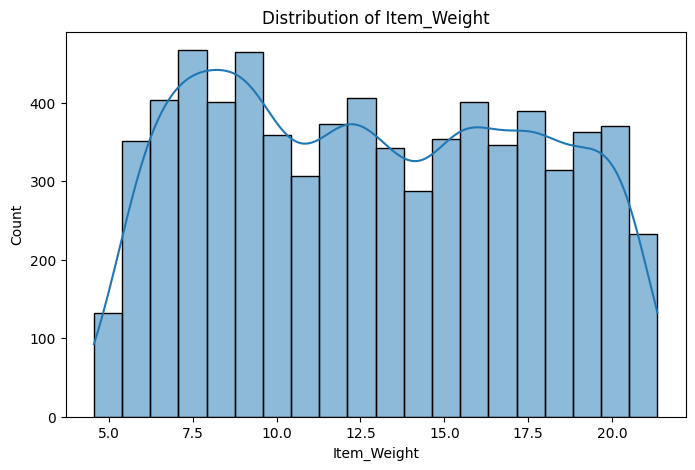

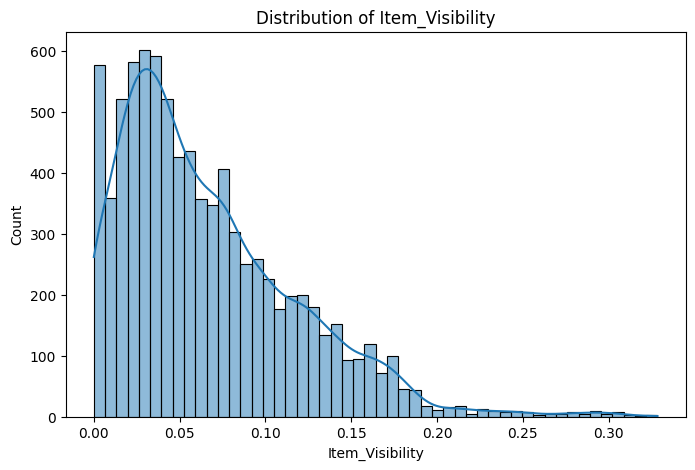

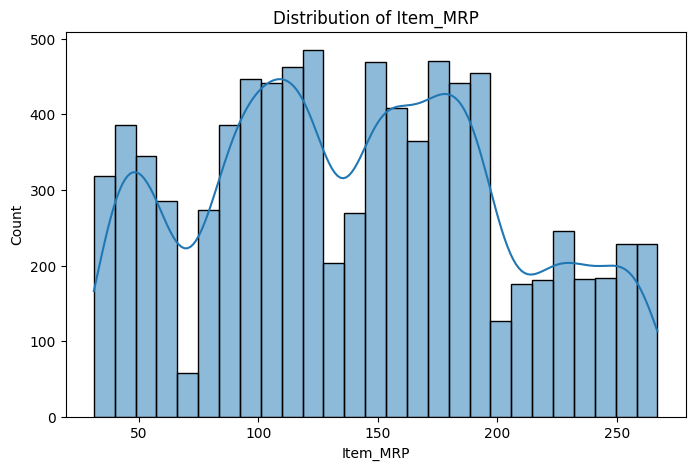

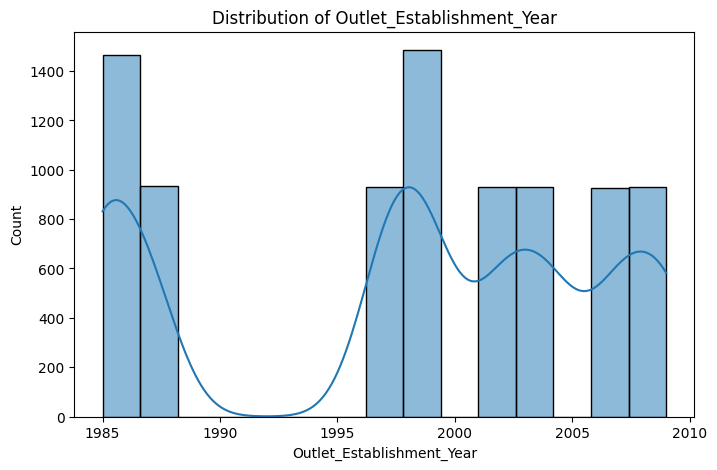

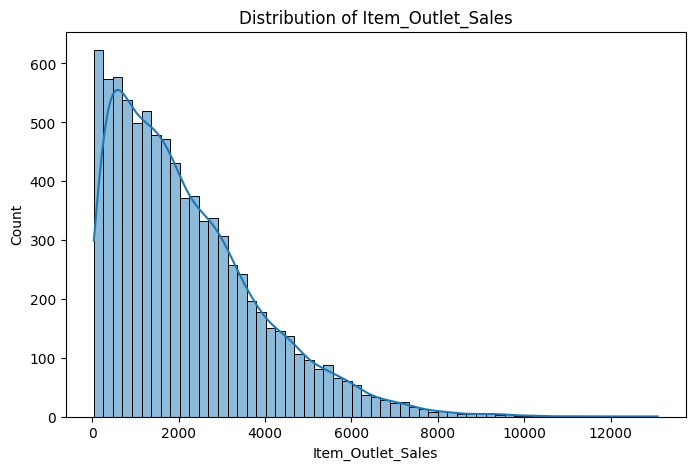

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Item_Outlet_Sales"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [5]:
df[numeric_cols].describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


### Categorical variables

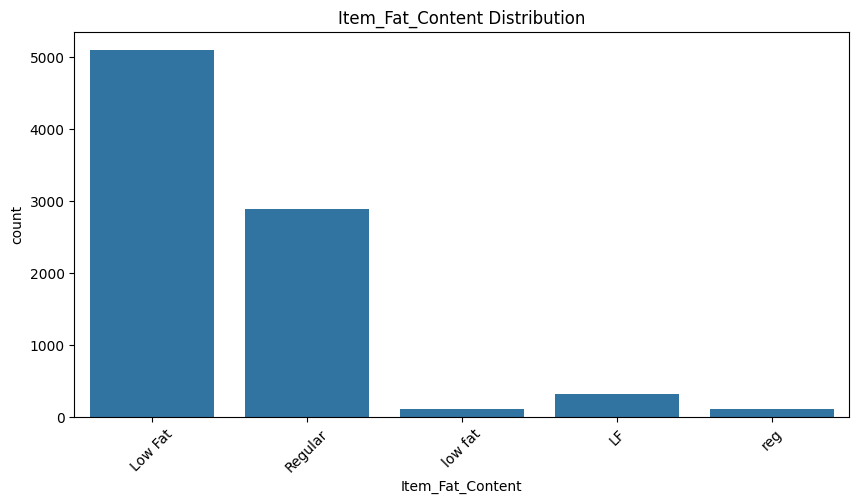

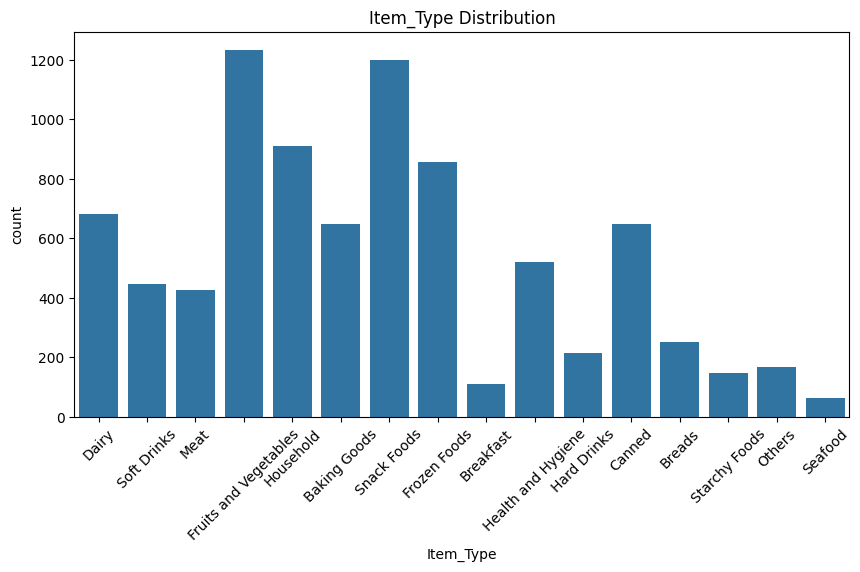

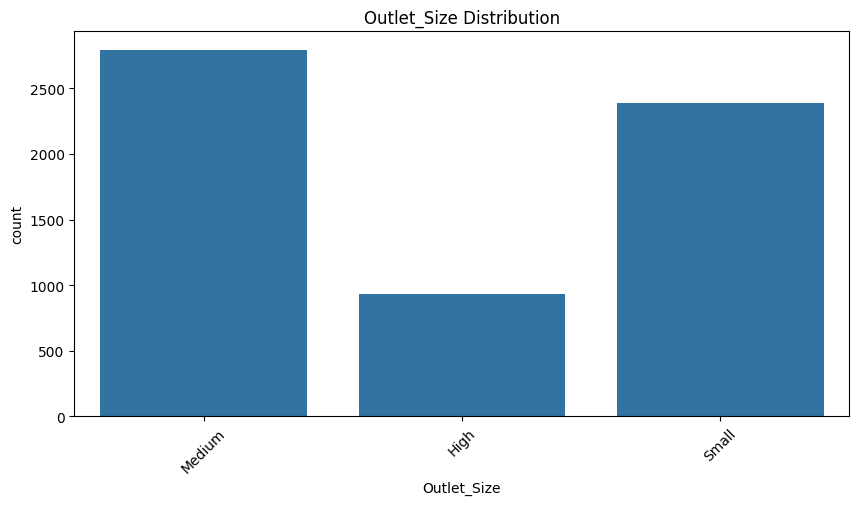

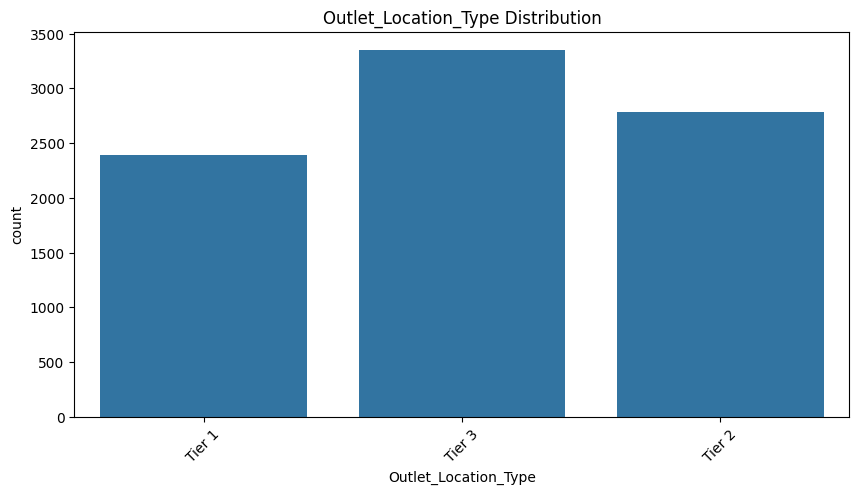

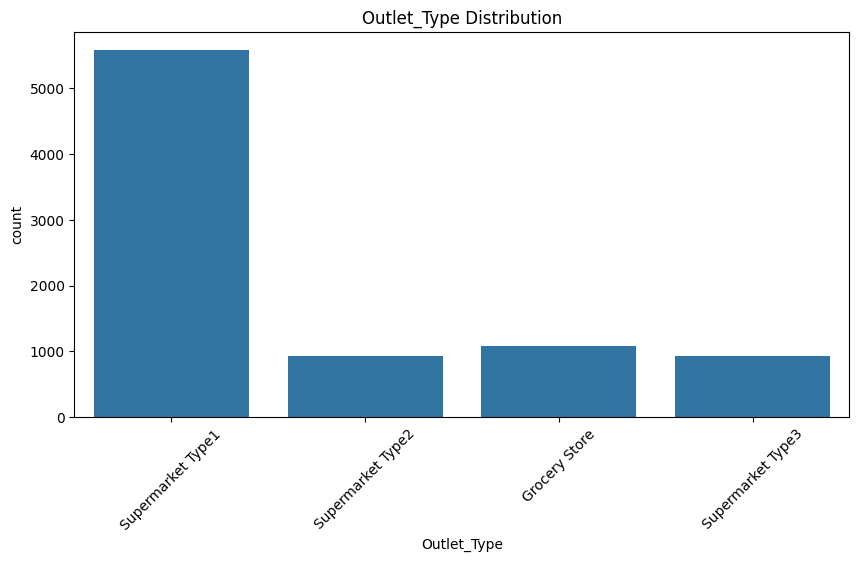

In [6]:
categorical_cols = [
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
]

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
    plt.show()

2. Bivariate Analysis
- Bivariate = analyzing the relationship between two variables.

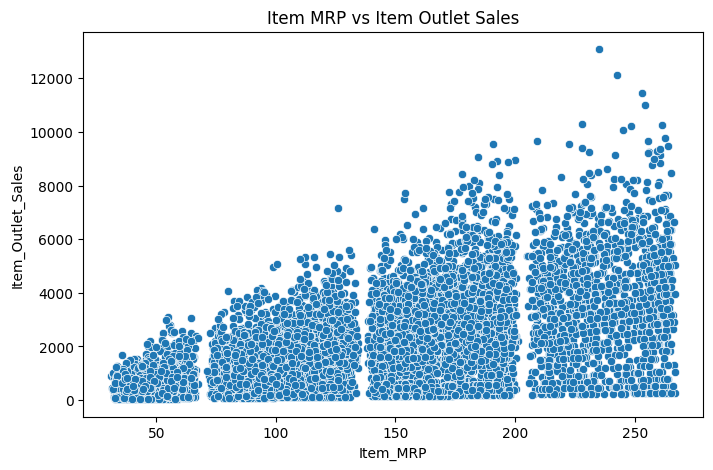

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Item_MRP",
    y="Item_Outlet_Sales"
)

plt.title("Item MRP vs Item Outlet Sales")
plt.show()

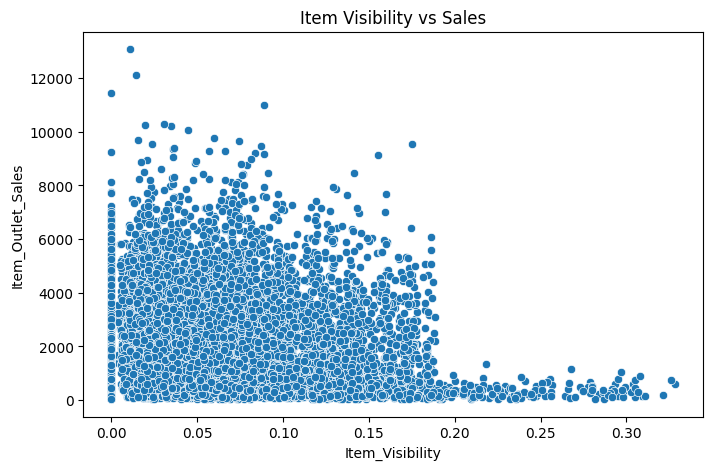

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Item_Visibility",
    y="Item_Outlet_Sales"
)

plt.title("Item Visibility vs Sales")
plt.show()

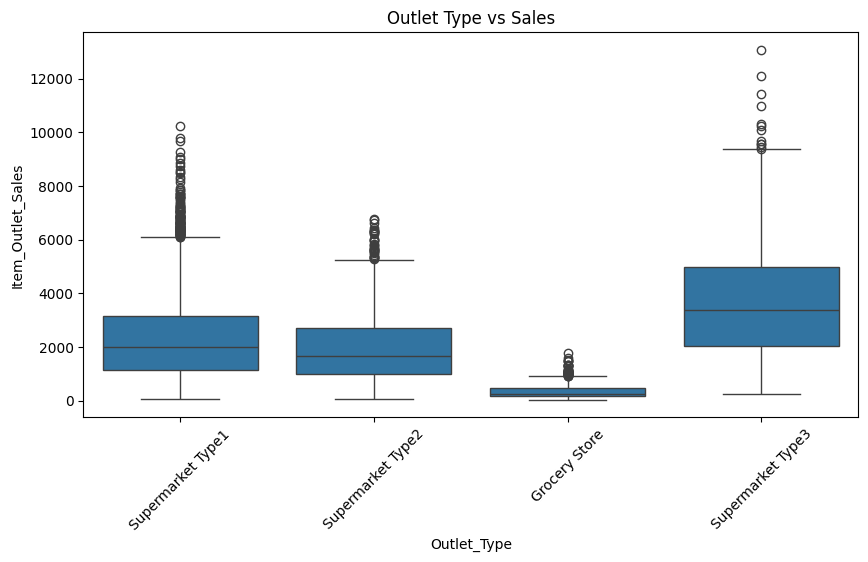

In [9]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Outlet_Type",
    y="Item_Outlet_Sales"
)

plt.xticks(rotation=45)
plt.title("Outlet Type vs Sales")
plt.show()

3. Multivariate Analysis
- Multivariate = analyzing three or more variables together.

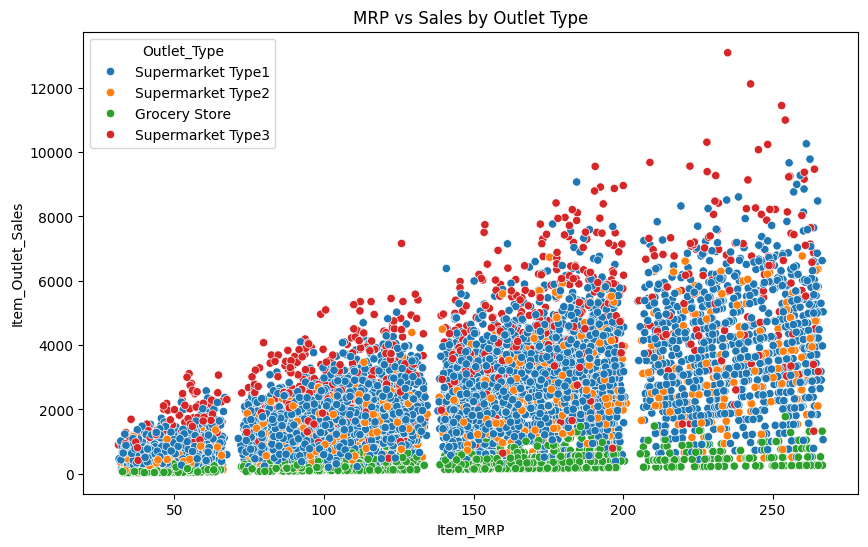

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Item_MRP",
    y="Item_Outlet_Sales",
    hue="Outlet_Type"
)

plt.title("MRP vs Sales by Outlet Type")
plt.show()

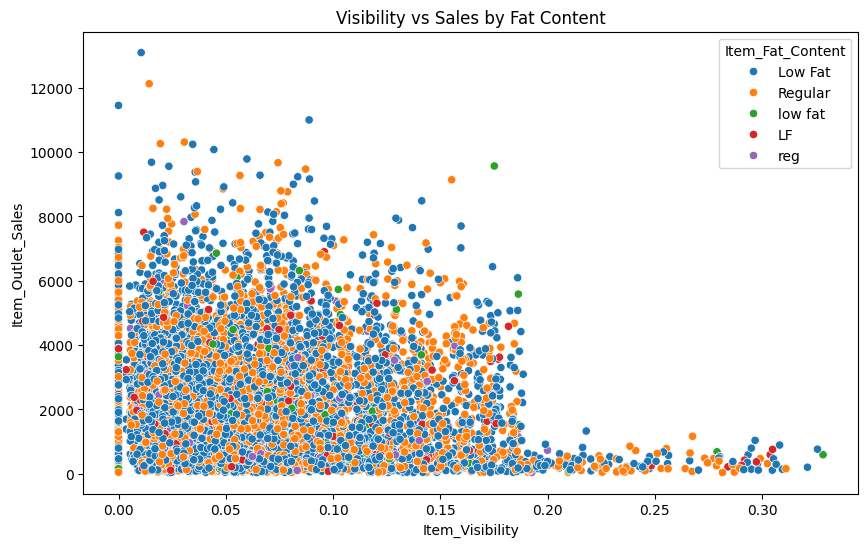

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Item_Visibility",
    y="Item_Outlet_Sales",
    hue="Item_Fat_Content"
)

plt.title("Visibility vs Sales by Fat Content")
plt.show()

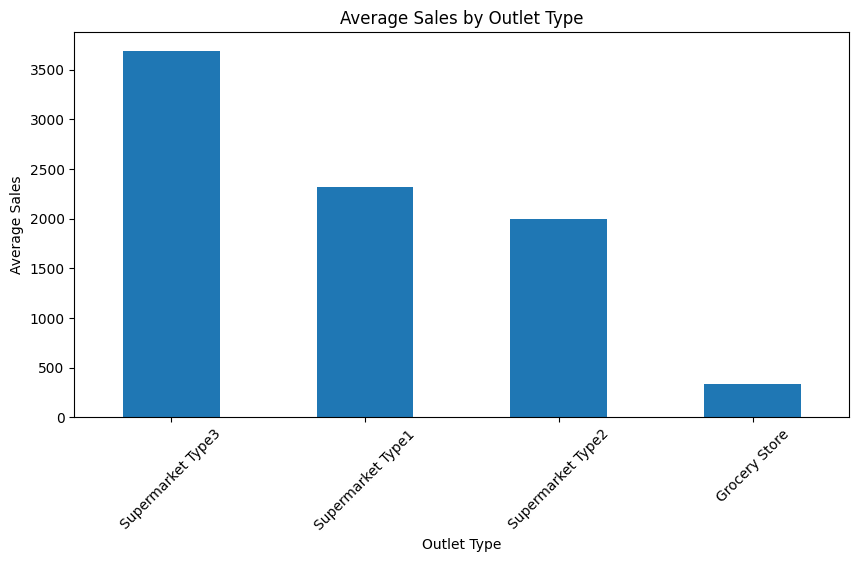

In [12]:
sales_by_outlet = df.groupby(
    "Outlet_Type"
)["Item_Outlet_Sales"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 5))

sales_by_outlet.plot(kind="bar")

plt.title("Average Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

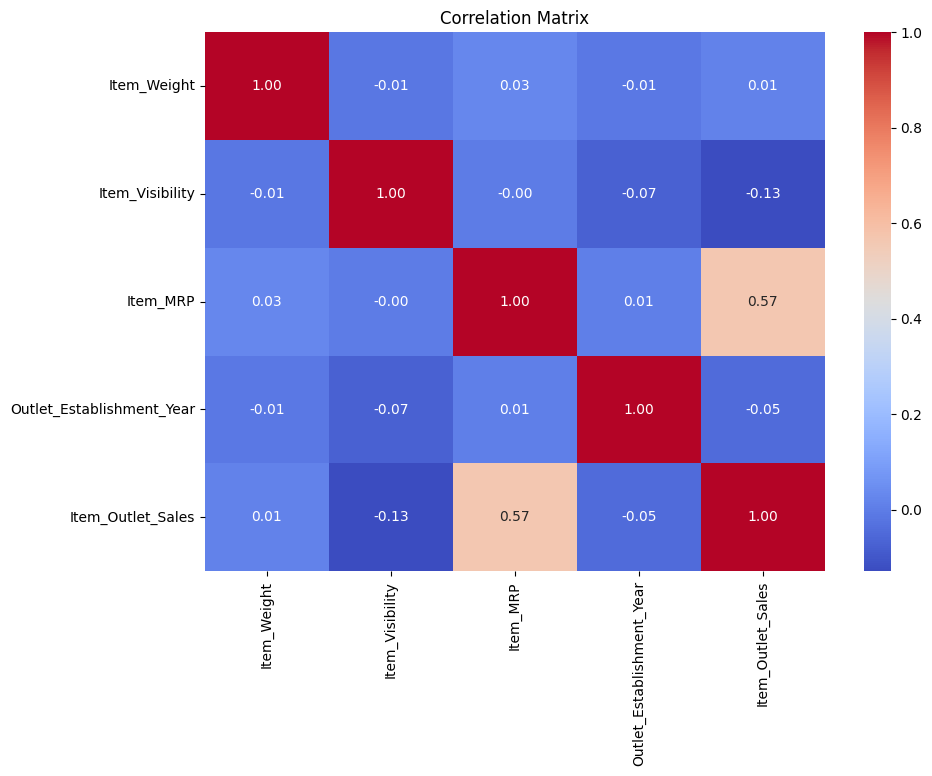

In [13]:
corr = df.select_dtypes(
    include="number"
).corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [14]:
for col in numeric_cols:
    print(col, ":", df[col].skew())

Item_Weight : 0.0824262091221237
Item_Visibility : 1.1670905496918396
Item_MRP : 0.1272022683110526
Outlet_Establishment_Year : -0.39664078591550556
Item_Outlet_Sales : 1.1775306028542796


In [15]:
df.groupby("Outlet_Type")[
    "Item_Outlet_Sales"
].agg([
    "mean",
    "median",
    "min",
    "max",
    "std"
])

,mean,median,min,max,std
Outlet_Type,,,,,
Grocery Store,339.828500,256.9988,33.2900,1775.6886,260.851582
Supermarket Type1,2316.181148,1990.7420,73.2380,10256.6490,1515.965558
Supermarket Type2,1995.498739,1655.1788,69.2432,6768.5228,1375.932889
Supermarket Type3,3694.038558,3364.9532,241.6854,13086.9648,2127.760054


In [16]:
item_sales = df.groupby(
    "Item_Type"
)["Item_Outlet_Sales"].mean().sort_values(
    ascending=False
)

print(item_sales)

Item_Type
Starchy Foods            2374.332773
Seafood                  2326.065928
Fruits and Vegetables    2289.009592
Snack Foods              2277.321739
Household                2258.784300
Dairy                    2232.542597
Canned                   2225.194904
Breads                   2204.132226
Meat                     2158.977911
Hard Drinks              2139.221622
Frozen Foods             2132.867744
Breakfast                2111.808651
Health and Hygiene       2010.000265
Soft Drinks              2006.511735
Baking Goods             1952.971207
Others                   1926.139702
Name: Item_Outlet_Sales, dtype: float64


In [17]:
location_sales = df.groupby(
    "Outlet_Location_Type"
)["Item_Outlet_Sales"].mean()

print(location_sales)

Outlet_Location_Type
Tier 1    1876.909159
Tier 2    2323.990559
Tier 3    2279.627651
Name: Item_Outlet_Sales, dtype: float64


In [18]:
pivot = pd.pivot_table(
    df,
    values="Item_Outlet_Sales",
    index="Outlet_Type",
    columns="Outlet_Location_Type",
    aggfunc="mean"
)

print(pivot)

Outlet_Location_Type       Tier 1       Tier 2       Tier 3
Outlet_Type                                                
Grocery Store          340.329723          NaN   339.351662
Supermarket Type1     2313.099451  2323.990559  2298.995256
Supermarket Type2             NaN          NaN  1995.498739
Supermarket Type3             NaN          NaN  3694.038558


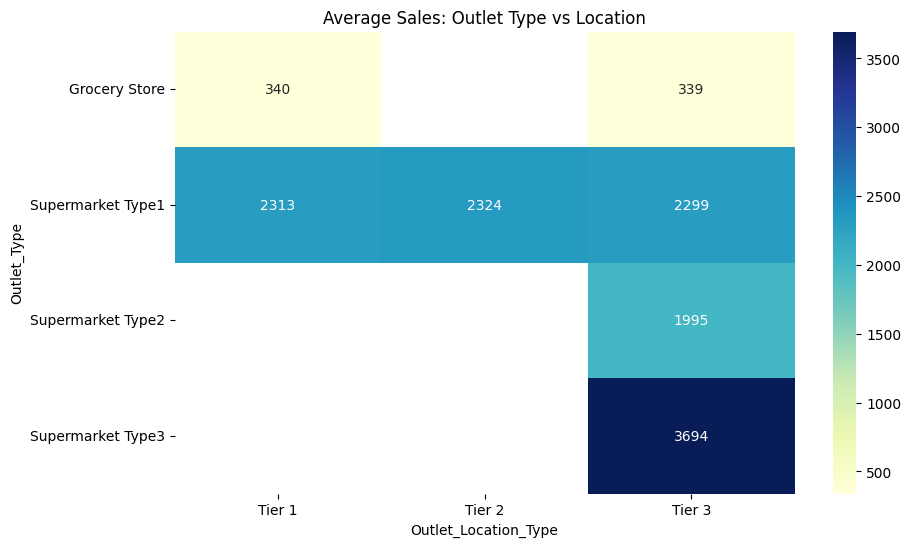

In [19]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Sales: Outlet Type vs Location")
plt.show()